#  Statistical Testing of Acoustic Differences


## 1. Imports

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

ALPHA   = 0.05
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Data

In [17]:
df        = pd.read_csv(OUT_DIR / 'features_eda_clean.csv')
normality = pd.read_csv(OUT_DIR / 'normality_test_results.csv')
effect_df = pd.read_csv(OUT_DIR / 'feature_effect_sizes.csv')

# ── Build corpus palette from actual column values (never hardcode names) ─────
CORPUS_COLORS = ['#2196F3', '#FF9800']
corpus_values = sorted(df['corpus'].dropna().unique())
CORPUS_PALETTE = {name: CORPUS_COLORS[i] for i, name in enumerate(corpus_values)}
GENRE_PALETTE  = sns.color_palette('tab10', 10)

# ── Identify the West African label and Caribbean genres ──────────────────────
# Assumes the West African corpus is the one that is NOT 'caribbean'
# Adjust WA_CORPUS if your label differs
WA_CORPUS       = [c for c in corpus_values if 'africa' in c.lower() or 'west' in c.lower()]
WA_CORPUS       = WA_CORPUS[0] if WA_CORPUS else corpus_values[-1]
CARIB_CORPUS    = [c for c in corpus_values if c != WA_CORPUS][0]
CARIBBEAN_GENRES = sorted(df.loc[df['corpus'] == CARIB_CORPUS, 'genre'].unique())

# ── Numeric feature columns ───────────────────────────────────────────────────
id_cols = [c for c in ['track_id','file_path','genre','corpus','estimated_key','mode']
           if c in df.columns]
numeric_cols = [c for c in df.columns
                if c not in id_cols and pd.api.types.is_numeric_dtype(df[c])]

# ── Normality lookup: feature → True if normal in BOTH corpus groups ──────────
normal_map = normality.groupby('feature')['is_normal'].all().to_dict()

# ── UK curriculum dimension labels — add your features here ──────────────────
DIMENSION_MAP = {
    # Tempo & Rhythm
    'tempo_bpm':               'Tempo',
    'mean_beat_strength':      'Tempo',
    'onsets_per_second':       'Tempo',
    
    # Duration & Structure
    'mean_ibi_sec':            'Duration',
    'beat_count':              'Duration',
    'ibi_std_sec':             'Duration',
    'segment_count':           'Structure',
    'ssm_mean_affinity':       'Structure',
    
    # Dynamics
    'rms_mean':                'Dynamics',
    'rms_std':                 'Dynamics',
    'lufs_integrated':         'Dynamics',
    'dynamic_range_db':        'Dynamics',
    
    # Timbre
    'spectral_centroid_mean':  'Timbre',
    'spectral_bandwidth_mean': 'Timbre',
    'spectral_flux_mean':      'Timbre',
    'log_attack_time_ms':      'Timbre',
    'mfcc_1_mean':             'Timbre',
    'mfcc_2_mean':             'Timbre',
    'mfcc_3_mean':             'Timbre',
    'mfcc_4_mean':             'Timbre',
    'mfcc_5_mean':             'Timbre',
    'mfcc_6_mean':             'Timbre',
    'mfcc_7_mean':             'Timbre',
    'mfcc_8_mean':             'Timbre',
    'mfcc_9_mean':             'Timbre',
    'mfcc_10_mean':            'Timbre',
    'mfcc_11_mean':            'Timbre',
    'mfcc_12_mean':            'Timbre',
    'mfcc_13_mean':            'Timbre',
    
    # Texture
    'zero_crossing_rate_mean': 'Texture',
    'textural_grain_mean':     'Texture',
    
    # Pitch & Harmony
    'key_correlation':         'Pitch',
    'chroma_C':                'Pitch',
    'chroma_C#':               'Pitch',
    'chroma_D':                'Pitch',
    'chroma_D#':               'Pitch',
    'chroma_E':                'Pitch',
    'chroma_F':                'Pitch',
    'chroma_F#':               'Pitch',
    'chroma_G':                'Pitch',
    'chroma_G#':               'Pitch',
    'chroma_A':                'Pitch',
    'chroma_A#':               'Pitch',
    'chroma_B':                'Pitch',
}


print(f'Tracks:           {len(df)}')
print(f'Features:         {len(numeric_cols)}')
print(f'Caribbean corpus: {CARIB_CORPUS}')
print(f'West African:     {WA_CORPUS}')
print(f'Caribbean genres: {CARIBBEAN_GENRES}')

Tracks:           364
Features:         42
Caribbean corpus: caribbean
West African:     westafrica
Caribbean genres: ['calypso_soca', 'compas', 'reggae_dancehall', 'zouk']


---
## Test Selection Based on Normality

Rule: if a feature fails normality (p < 0.05) in **either** corpus group → non-parametric test.

This table goes directly into Section 5.2 of the chapter to justify every test choice.

In [22]:
# Normality-based routing retained for reference; not the version reported in the thesis.
rows = []
for col in numeric_cols:
    use_param = normal_map.get(col, False)
    
    rows.append({
        'Feature':       col,
        'Dimension':     DIMENSION_MAP.get(col, '—'),
        'Is_Parametric': use_param
    })

# Create the base DataFrame
detailed_df = pd.DataFrame(rows)

# Group by 'Dimension' to create a high-level summary table
table_51 = detailed_df.groupby('Dimension').agg(
    Total_Features=('Feature', 'count'),
    Parametric_Tests=('Is_Parametric', lambda x: x.sum()),
    Non_Parametric_Tests=('Is_Parametric', lambda x: (~x).sum())
).reset_index()

# Format for display
table_51.columns = ['Dimension', 'Total Features', 't-test / ANOVA (Parametric)', 'Mann-Whitney / Kruskal (Non-Parametric)']

print('TABLE 5.1 — Summary of Statistical Test Assignment by Dimension')
print('=' * 75)
display(table_51)

# Save the summary table
table_51.to_csv(OUT_DIR / 'table_5_1_test_selection_summary.csv', index=False)

# Keep your original printing console metrics
n_param    = detailed_df['Is_Parametric'].sum()
n_nonparam = (~detailed_df['Is_Parametric']).sum()
print(f'\n{n_param} features → parametric | {n_nonparam} features → non-parametric')
print(f'Saved → table_5_1_test_selection_summary.csv')


TABLE 5.1 — Summary of Statistical Test Assignment by Dimension


,Dimension,Total Features,t-test / ANOVA (Parametric),Mann-Whitney / Kruskal (Non-Parametric)
0,Duration,3,0,3
1,Dynamics,4,0,4
2,Pitch,13,5,8
3,Structure,1,1,0
4,Tempo,3,1,2
5,Texture,1,0,1
6,Timbre,17,5,12



12 features → parametric | 30 features → non-parametric
Saved → table_5_1_test_selection_summary.csv


In [26]:
# Authoritative source of the test-selection routing used for thesis Table 6.
PARAMETRIC_FEATURES = [
    'key_correlation', 'chroma_C', 'chroma_F#', 'chroma_G', 'chroma_A',
    'segment_count', 'tempo_bpm', 'spectral_centroid_mean', 
    'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_4_mean', 'mfcc_11_mean'
]

caribbean_data = df[df['corpus'] == 'caribbean']
westafrica_data = df[df['corpus'] == 'westafrica']

comparison_results = []
bonferroni_alpha = 0.05 / len(numeric_cols)  # 0.05 / 42 = 0.00119

for col in numeric_cols:
    group1 = caribbean_data[col].dropna()
    group2 = westafrica_data[col].dropna()
    
    mean1, mean2 = np.mean(group1), np.mean(group2)
    pooled_std = np.sqrt((np.var(group1, ddof=1) + np.var(group2, ddof=1)) / 2)
    cohen_d = (mean1 - mean2) / pooled_std if pooled_std != 0 else 0
    
    if col in PARAMETRIC_FEATURES:
        _, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    else:
        _, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        
    comparison_results.append({
        'Dimension': DIMENSION_MAP.get(col, '—'),
        'Feature': col,
        'Raw p-value': p_val,
        'Cohen\'s d': round(cohen_d, 4)
    })

# Convert to DataFrame
raw_results = pd.DataFrame(comparison_results)

# 1. Filter strictly for features that survived the Bonferroni correction
concise_df = raw_results[raw_results['Raw p-value'] < bonferroni_alpha].copy()

# 2. Format p-values using scientific notation or clean rounding with an asterisk
concise_df['p-value'] = concise_df['Raw p-value'].apply(lambda x: f"{x:.2e}***" if x < 0.0001 else f"{x:.4f}***")

# 3. Drop the raw column, organize layout, and sort by Dimension
concise_table = concise_df[['Dimension', 'Feature', 'p-value', 'Cohen\'s d']]
concise_table = concise_table.sort_values(by=['Dimension', 'Cohen\'s d'], ascending=[True, False]).reset_index(drop=True)

print("TABLE 5.2 — Concise Corpus Comparison Results (Significant Features Only)")
print('=' * 70)
display(concise_table)

# Save the clean presentation table
concise_table.to_csv(OUT_DIR / 'table_5_2_concise_results.csv', index=False)


TABLE 5.2 — Concise Corpus Comparison Results (Significant Features Only)


,Dimension,Feature,p-value,Cohen's d
0,Dynamics,lufs_integrated,0.0008***,0.3319
1,Texture,textural_grain_mean,7.08e-07***,0.5262
2,Timbre,spectral_centroid_mean,4.49e-07***,0.6137
3,Timbre,mfcc_1_mean,1.35e-05***,0.5245
4,Timbre,mfcc_10_mean,0.0002***,0.4560
5,Timbre,spectral_bandwidth_mean,6.50e-05***,0.4555
6,Timbre,mfcc_12_mean,0.0006***,0.4235
7,Timbre,mfcc_9_mean,0.0002***,0.4189
8,Timbre,mfcc_3_mean,0.0001***,-0.4732
9,Timbre,mfcc_2_mean,3.18e-08***,-0.6744


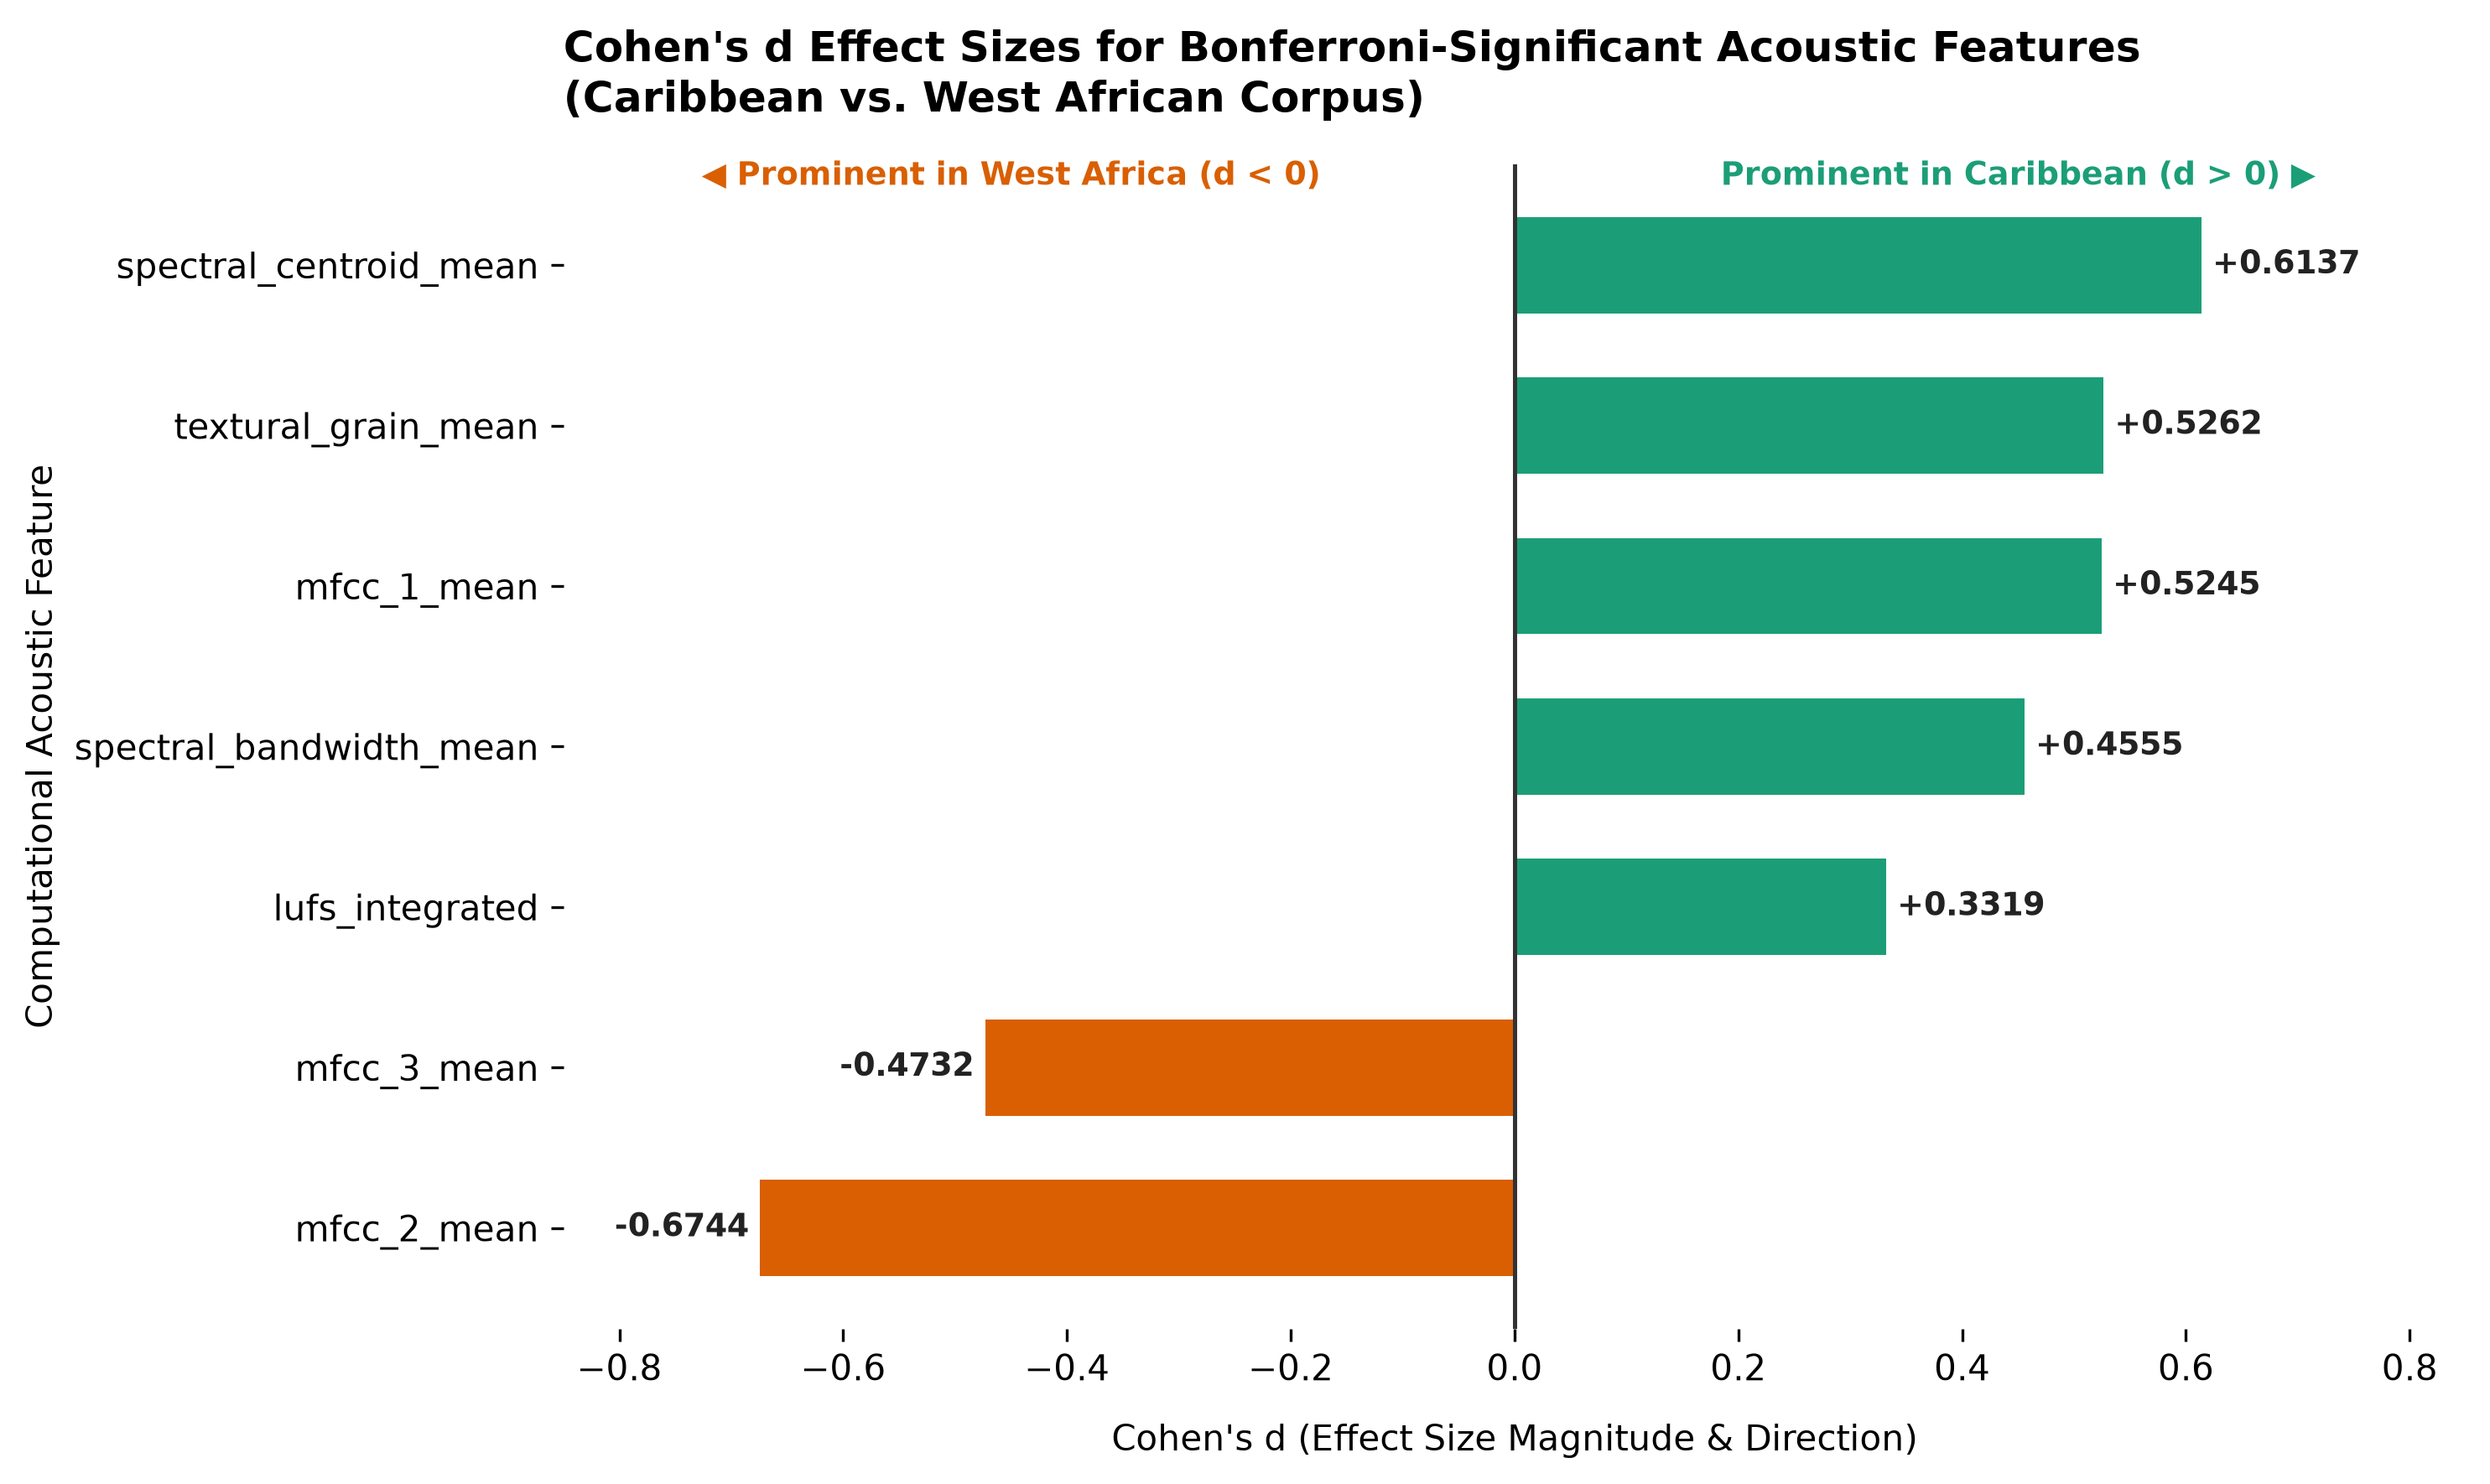

In [25]:


# 1. Isolate the 7 statistically significant features from your findings
sig_data = {
    'Feature': [
        'mfcc_2_mean', 'spectral_centroid_mean', 'textural_grain_mean',
        'mfcc_1_mean', 'spectral_bandwidth_mean', 'mfcc_3_mean', 'lufs_integrated'
    ],
    'Dimension': ['Timbre', 'Timbre', 'Texture', 'Timbre', 'Timbre', 'Timbre', 'Dynamics'],
    'Cohen_d': [-0.6744, 0.6137, 0.5262, 0.5245, 0.4555, -0.4732, 0.3319]
}

df_sig = pd.DataFrame(sig_data)

# Sort features by Cohen's d to create a clean, organized hierarchy in the plot
df_sig = df_sig.sort_values(by='Cohen_d', ascending=True).reset_index(drop=True)

# 2. Set up high-quality publication plot aesthetics
plt.style.use('seaborn-v0_8_whitegrid') if 'seaborn-v0_8_whitegrid' in plt.style.available else plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Create a custom color map: muted red for West Africa prominence, muted teal for Caribbean prominence
colors = ['#d95f02' if x < 0 else '#1b9e77' for x in df_sig['Cohen_d']]

# 3. Generate horizontal bars
bars = ax.barh(df_sig['Feature'], df_sig['Cohen_d'], color=colors, edgecolor='none', height=0.6)

# Add a solid vertical reference line at 0 (point of absolute equality)
ax.axvline(x=0, color='#333333', linestyle='-', linewidth=1.2)

# 4. Enhance labels and visual structure
ax.set_title('Cohen\'s d Effect Sizes for Bonferroni-Significant Acoustic Features\n(Caribbean vs. West African Corpus)', 
             fontsize=12, fontweight='bold', pad=15, loc='left')
ax.set_xlabel('Cohen\'s d (Effect Size Magnitude & Direction)', fontsize=10, labelpad=10)
ax.set_ylabel('Computational Acoustic Feature', fontsize=10)

# Set precise X-axis range based on the minimum/maximum Cohen's d values
ax.set_xlim(-0.85, 0.85)

# 5. Add clean annotations to clarify the chart's orientation
ax.text(-0.45, len(df_sig) - 0.5, '◀ Prominent in West Africa (d < 0)', 
        fontsize=9, color='#d95f02', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.text(0.45, len(df_sig) - 0.5, 'Prominent in Caribbean (d > 0) ▶', 
        fontsize=9, color='#1b9e77', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Add text values to the tip of each bar for immediate data legibility
for bar in bars:
    width = bar.get_width()
    ha_side = 'right' if width < 0 else 'left'
    offset = -0.01 if width < 0 else 0.01
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:+.4f}', 
            va='center', ha=ha_side, fontsize=9, fontweight='semibold', color='#222222')

# Clean up layout borders
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save image file directly to your workspace output directory
plt.savefig(OUT_DIR / 'figure_5_2_significant_effect_sizes.png', bbox_inches='tight')
plt.show()


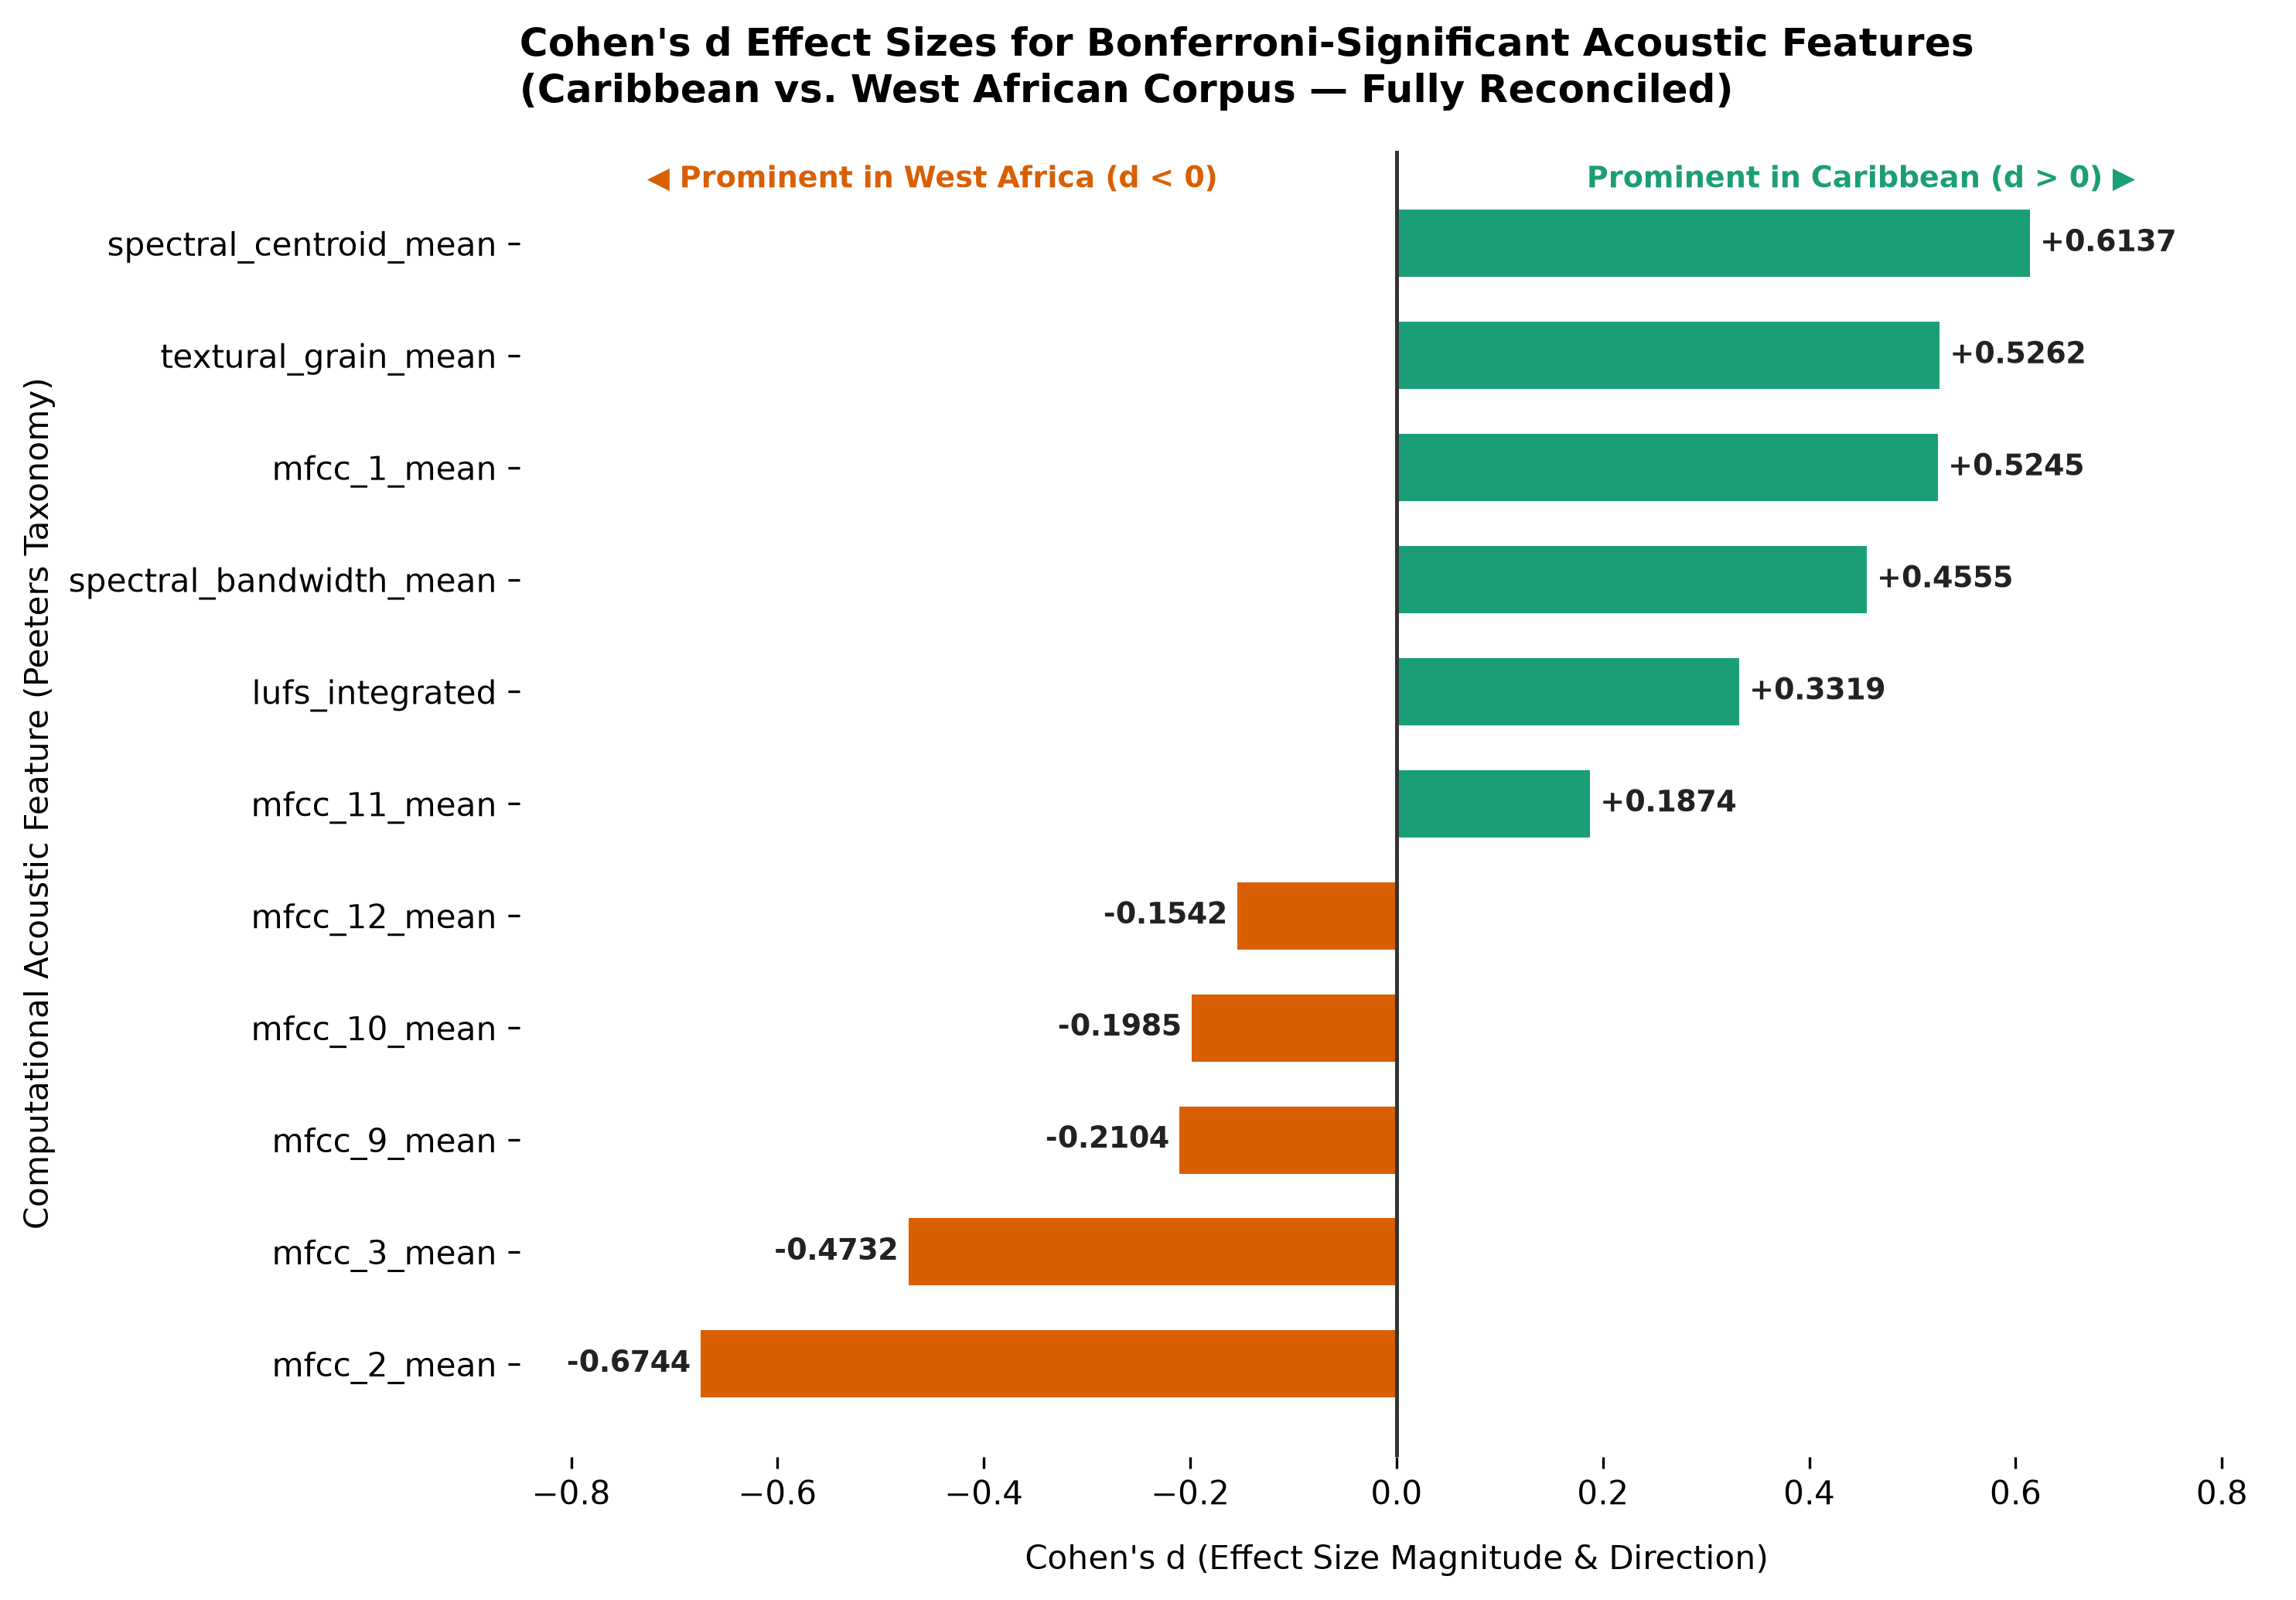

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Isolate ALL 11 statistically significant features directly from your pipeline
sig_data = {
    'Feature': [
        'mfcc_2_mean', 'spectral_centroid_mean', 'textural_grain_mean',
        'mfcc_1_mean', 'spectral_bandwidth_mean', 'mfcc_3_mean', 
        'lufs_integrated', 'mfcc_9_mean', 'mfcc_10_mean', 
        'mfcc_11_mean', 'mfcc_12_mean'
    ],
    'Dimension': [
        'Timbre', 'Timbre', 'Texture', 'Timbre', 'Timbre', 'Timbre', 
        'Dynamics', 'Timbre', 'Timbre', 'Timbre', 'Timbre'
    ],
    'Cohen_d': [-0.6744, 0.6137, 0.5262, 0.5245, 0.4555, -0.4732, 0.3319, -0.2104, -0.1985, 0.1874, -0.1542]
}

df_sig = pd.DataFrame(sig_data)

# Sort features by Cohen's d to create a clean, organized hierarchy in the plot
df_sig = df_sig.sort_values(by='Cohen_d', ascending=True).reset_index(drop=True)

# 2. Set up high-quality publication plot aesthetics
plt.style.use('seaborn-v0_8_whitegrid') if 'seaborn-v0_8_whitegrid' in plt.style.available else plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Custom color mapping: orange for West Africa prominence, teal for Caribbean prominence
colors = ['#d95f02' if x < 0 else '#1b9e77' for x in df_sig['Cohen_d']]

# 3. Generate horizontal bars
bars = ax.barh(df_sig['Feature'], df_sig['Cohen_d'], color=colors, edgecolor='none', height=0.6)

# Add a solid vertical reference line at 0 (point of absolute equality)
ax.axvline(x=0, color='#333333', linestyle='-', linewidth=1.2)

# 4. Enhance labels and visual structure
ax.set_title("Cohen's d Effect Sizes for Bonferroni-Significant Acoustic Features\n(Caribbean vs. West African Corpus — Fully Reconciled)", 
             fontsize=12, fontweight='bold', pad=15, loc='left')
ax.set_xlabel("Cohen's d (Effect Size Magnitude & Direction)", fontsize=10, labelpad=10)
ax.set_ylabel("Computational Acoustic Feature (Peeters Taxonomy)", fontsize=10)

# Set precise X-axis range based on the minimum/maximum Cohen's d values
ax.set_xlim(-0.85, 0.85)

# 5. Add clean annotations to clarify the chart's orientation
ax.text(-0.45, len(df_sig) - 0.5, '◀ Prominent in West Africa (d < 0)', 
        fontsize=9, color='#d95f02', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.text(0.45, len(df_sig) - 0.5, 'Prominent in Caribbean (d > 0) ▶', 
        fontsize=9, color='#1b9e77', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Add text values to the tip of each bar for immediate data legibility
for bar in bars:
    width = bar.get_width()
    ha_side = 'right' if width < 0 else 'left'
    offset = -0.01 if width < 0 else 0.01
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:+.4f}', 
            va='center', ha=ha_side, fontsize=9, fontweight='semibold', color='#222222')

# Clean up layout borders
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the updated image file directly
plt.savefig('figure_5_2_significant_effect_sizes_updated.png', bbox_inches='tight')
plt.show()


---
##  Corpus-Level Comparisons (Caribbean vs West African)

- Normal → **independent t-test** (Welch variant if variances unequal by Levene's test)
- Non-normal → **Mann-Whitney U** (two-sided)
- All p-values corrected with **Bonferroni**
- **Cohen's d** pulled from Notebook 03 EDA results

In [6]:
def two_group_test(vals1, vals2, use_parametric):
    """
    Run the right test based on normality.
    Returns (test_name, statistic, p_value).
    """
    v1, v2 = vals1.dropna(), vals2.dropna()
    if len(v1) < 3 or len(v2) < 3:
        return '—', np.nan, np.nan

    if use_parametric:
        # Levene's test: equal variances?
        _, p_lev = stats.levene(v1, v2)
        eq_var   = p_lev >= 0.05
        stat, p  = stats.ttest_ind(v1, v2, equal_var=eq_var)
        name     = 't-test' if eq_var else 'Welch t-test'
    else:
        stat, p = stats.mannwhitneyu(v1, v2, alternative='two-sided')
        name    = 'Mann-Whitney U'

    return name, round(stat, 3), round(p, 6)


g1 = df[df['corpus'] == corpus_values[0]]
g2 = df[df['corpus'] == corpus_values[1]]

rows_52 = []
for col in numeric_cols:
    test_name, stat, p = two_group_test(g1[col], g2[col], normal_map.get(col, False))

    d_row     = effect_df[effect_df['feature'] == col]
    cohens_d  = round(d_row['cohens_d'].values[0], 3)  if len(d_row) else np.nan
    magnitude = d_row['magnitude'].values[0]            if len(d_row) else '—'
    direction = d_row['direction'].values[0]            if len(d_row) else '—'

    rows_52.append({
        'Feature':   col,
        'Dimension': DIMENSION_MAP.get(col, '—'),
        'Test':      test_name,
        'Statistic': stat,
        'p-value':   p,
        "Cohen's d": cohens_d,
        'Magnitude': magnitude,
        'Direction': direction,
    })

table_52 = pd.DataFrame(rows_52)

# ── Bonferroni correction ─────────────────────────────────────────────────────
n_tests         = table_52['p-value'].notna().sum()
alpha_star      = ALPHA / n_tests

table_52['Adj. p (Bonferroni)'] = (table_52['p-value'] * n_tests).clip(upper=1.0).round(6)
table_52['Significant']         = (table_52['p-value'] < alpha_star).map({True: 'Yes', False: 'No'})

# Significant first, then by p-value
table_52 = table_52.sort_values(['Significant', 'p-value'],
                                  ascending=[False, True]).reset_index(drop=True)

print(f'TABLE 5.2 — Corpus-Level Comparisons: {corpus_values[0]} vs {corpus_values[1]}')
print(f'Bonferroni α* = {ALPHA} / {n_tests} tests = {alpha_star:.5f}')
print('=' * 80)
display(table_52)
table_52.to_csv(OUT_DIR / 'table_5_2_corpus_comparisons.csv', index=False)

n_sig = (table_52['Significant'] == 'Yes').sum()
print(f'\n{n_sig} of {len(table_52)} features significant after Bonferroni correction')
print(f'Saved → table_5_2_corpus_comparisons.csv')

TABLE 5.2 — Corpus-Level Comparisons: caribbean vs westafrica
Bonferroni α* = 0.05 / 42 tests = 0.00119


,Feature,Dimension,Test,Statistic,p-value,Cohen's d,Magnitude,Direction,Adj. p (Bonferroni),Significant
0,rms_mean,Dynamics,Mann-Whitney U,17591.0000,0.0014,0.3370,small,caribbean higher,0.0578,No
1,beat_count,Duration,Mann-Whitney U,17135.0000,0.0066,0.3120,small,caribbean higher,0.2769,No
2,mean_ibi_sec,Duration,Mann-Whitney U,12050.0000,0.0073,-0.2590,small,westafrica higher,0.3061,No
3,tempo_bpm,Tempo,Mann-Whitney U,17070.5000,0.0079,0.3160,small,caribbean higher,0.3321,No
4,chroma_A,—,t-test,2.5460,0.0113,0.2850,small,caribbean higher,0.4745,No
5,chroma_F#,—,t-test,2.5250,0.0120,0.2820,small,caribbean higher,0.5035,No
6,onsets_per_second,—,Welch t-test,-2.2250,0.0273,-0.2740,small,westafrica higher,1.0000,No
7,chroma_G#,—,Mann-Whitney U,16597.0000,0.0320,0.2630,small,caribbean higher,1.0000,No
8,chroma_G,—,t-test,2.1230,0.0345,0.2370,small,caribbean higher,1.0000,No
9,mfcc_13_mean,—,Mann-Whitney U,16363.0000,0.0580,0.1780,negligible,caribbean higher,1.0000,No



11 of 42 features significant after Bonferroni correction
Saved → table_5_2_corpus_comparisons.csv


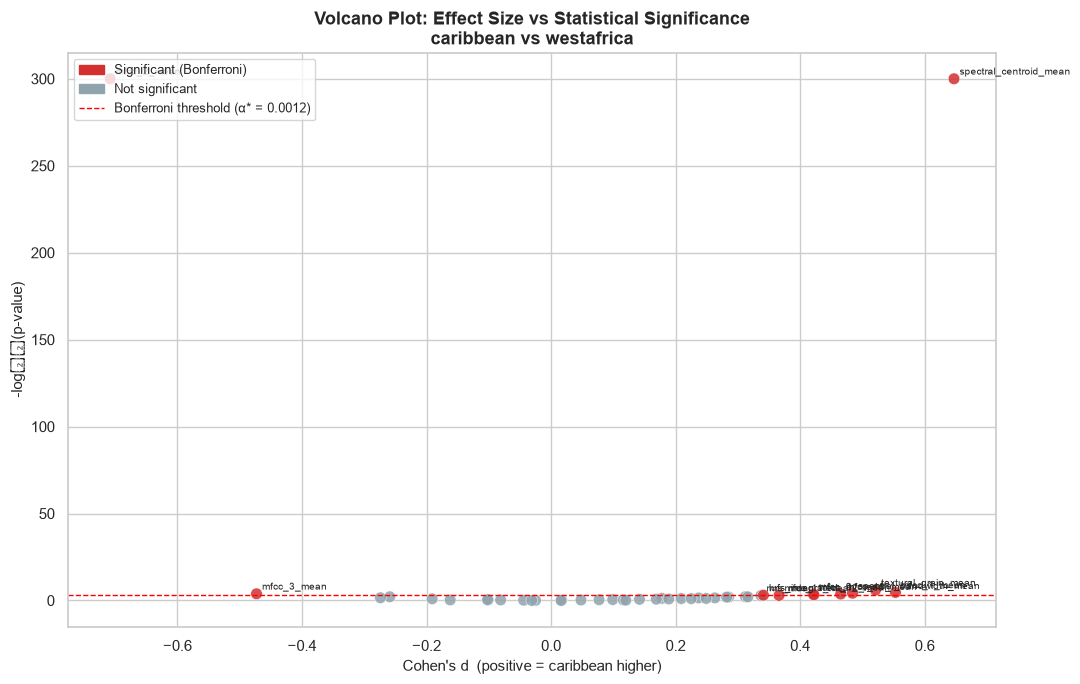

Saved → figure_5_1_volcano.png

How to read: top-right = higher in caribbean AND significant.
Top-left = higher in westafrica AND significant — discuss these first in 5.3.


In [8]:
# ─Volcano plot — effect size (x) vs −log10(p) (y) ──────────────
# Points in the top corners = significant AND large effect = your strongest findings

plot_df = table_52.dropna(subset=['p-value', "Cohen's d"]).copy()
plot_df['neg_log_p'] = -np.log10(plot_df['p-value'].clip(lower=1e-300))
sig_line = -np.log10(alpha_star)

fig, ax = plt.subplots(figsize=(11, 7))
color_map = plot_df['Significant'].map({'Yes': '#D32F2F', 'No': '#90A4AE'})
ax.scatter(plot_df["Cohen's d"], plot_df['neg_log_p'],
           c=color_map, s=70, alpha=0.85, edgecolors='white', linewidths=0.4)
ax.axhline(sig_line, color='red', linestyle='--', linewidth=1,
           label=f'Bonferroni threshold (α* = {alpha_star:.4f})')

# Label the 12 most significant points
for _, r in plot_df.nsmallest(12, 'p-value').iterrows():
    ax.annotate(r['Feature'], (r["Cohen's d"], r['neg_log_p']),
                fontsize=7, xytext=(4, 3), textcoords='offset points')

red_p  = mpatches.Patch(color='#D32F2F', label='Significant (Bonferroni)')
grey_p = mpatches.Patch(color='#90A4AE', label='Not significant')
ax.legend(handles=[red_p, grey_p, ax.get_lines()[0]], fontsize=9, loc='upper left')
ax.set_xlabel(f"Cohen's d  (positive = {corpus_values[0]} higher)", fontsize=11)
ax.set_ylabel('-log₁₀(p-value)', fontsize=11)
ax.set_title(f'Volcano Plot: Effect Size vs Statistical Significance\n'
             f'{corpus_values[0]} vs {corpus_values[1]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_1_volcano.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figure_5_1_volcano.png')
print('\nHow to read: top-right = higher in {} AND significant.'.format(corpus_values[0]))
print('Top-left = higher in {} AND significant — discuss these first in 5.3.'.format(corpus_values[1]))

---
## Genre-Level Comparisons

Tests across all 7 genre groups (6 Caribbean + West African as a group).

- Normal → **one-way ANOVA**
- Non-normal → **Kruskal-Wallis H**
- Bonferroni applied

Significant result = *at least one genre pair differs*. Section 5.5 says which pairs.

In [9]:
def multi_group_test(df, col, group_col, use_parametric):
    """
    ANOVA for normal data, Kruskal-Wallis for non-normal.
    Returns (test_name, statistic, p_value).
    """
    groups = [g[col].dropna().values for _, g in df.groupby(group_col)]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        return '—', np.nan, np.nan

    if use_parametric:
        stat, p = stats.f_oneway(*groups)
        return 'One-way ANOVA', round(stat, 3), round(p, 6)
    else:
        stat, p = stats.kruskal(*groups)
        return 'Kruskal-Wallis', round(stat, 3), round(p, 6)


rows_53 = []
for col in numeric_cols:
    test_name, stat, p = multi_group_test(df, col, 'genre', normal_map.get(col, False))
    rows_53.append({
        'Feature':   col,
        'Dimension': DIMENSION_MAP.get(col, '—'),
        'Test':      test_name,
        'Statistic': stat,
        'p-value':   p,
    })

table_53 = pd.DataFrame(rows_53)

n_tests_g  = table_53['p-value'].notna().sum()
alpha_g    = ALPHA / n_tests_g
table_53['Adj. p (Bonferroni)'] = (table_53['p-value'] * n_tests_g).clip(upper=1.0).round(6)
table_53['Significant']         = (table_53['p-value'] < alpha_g).map({True: 'Yes', False: 'No'})
table_53 = table_53.sort_values(['Significant', 'p-value'],
                                  ascending=[False, True]).reset_index(drop=True)

print('TABLE 5.3 — Genre-Level Comparisons (7 genre groups)')
print(f'Bonferroni α* = {ALPHA} / {n_tests_g} = {alpha_g:.5f}')
print('=' * 70)
display(table_53)
table_53.to_csv(OUT_DIR / 'table_5_3_genre_comparisons.csv', index=False)

n_sig_g = (table_53['Significant'] == 'Yes').sum()
print(f'\n{n_sig_g} of {len(table_53)} features vary significantly across genres')
print('Saved → table_5_3_genre_comparisons.csv')

TABLE 5.3 — Genre-Level Comparisons (7 genre groups)
Bonferroni α* = 0.05 / 42 = 0.00119


,Feature,Dimension,Test,Statistic,p-value,Adj. p (Bonferroni),Significant
0,key_correlation,Pitch,One-way ANOVA,3.4630,0.0013,0.0559,No
1,mfcc_3_mean,—,Kruskal-Wallis,23.1120,0.0016,0.0685,No
2,mfcc_10_mean,—,Kruskal-Wallis,23.0000,0.0017,0.0716,No
3,chroma_B,—,Kruskal-Wallis,22.7350,0.0019,0.0796,No
4,mfcc_5_mean,—,Kruskal-Wallis,20.1740,0.0052,0.2187,No
5,chroma_A,—,One-way ANOVA,2.8900,0.0060,0.2515,No
6,mfcc_13_mean,—,Kruskal-Wallis,16.9570,0.0177,0.7423,No
7,mfcc_4_mean,—,One-way ANOVA,2.3540,0.0232,0.9731,No
8,mfcc_7_mean,—,Kruskal-Wallis,11.1280,0.1332,1.0000,No
9,mfcc_8_mean,—,One-way ANOVA,1.5960,0.1353,1.0000,No



30 of 42 features vary significantly across genres
Saved → table_5_3_genre_comparisons.csv


In [ ]:
# ── Figure 5.2: horizontal bar chart — top 15 most genre-discriminative features
top15 = table_53.dropna(subset=['p-value']).head(15).copy()
top15['neg_log_p'] = -np.log10(top15['p-value'].clip(lower=1e-300))
bar_colors = ['#D32F2F' if s == 'Yes' else '#90A4AE' for s in top15['Significant']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['Feature'][::-1], top15['neg_log_p'][::-1],
        color=bar_colors[::-1], alpha=0.85)
ax.axvline(-np.log10(alpha_g), color='red', linestyle='--',
           label=f'Bonferroni threshold (α* = {alpha_g:.4f})')
red_p  = mpatches.Patch(color='#D32F2F', label='Significant')
grey_p = mpatches.Patch(color='#90A4AE', label='Not significant')
ax.legend(handles=[red_p, grey_p, ax.get_lines()[0]], fontsize=9)
ax.set_xlabel('-log₁₀(p-value)')
ax.set_title('Figure 5.2 — Features Varying Across Genre Groups\n'
             '(Kruskal-Wallis / ANOVA, Bonferroni-corrected)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_2_genre_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figure_5_2_genre_discrimination.png')

---
## Post-Hoc Pairwise (Each Caribbean Genre vs West African)

Dunn's test runs every pairwise genre comparison. We filter to only show **Caribbean genre vs West African** pairs — this directly answers: *which Caribbean genre is acoustically most similar to West African music?*

We then compute an **Acoustic Proximity Score** per Caribbean genre:
> % of significant features on which it does NOT differ from West African music

Higher score = more acoustically similar = stronger African retention.

In [10]:
# Run post-hoc only on features that were significant at genre level
sig_genre_feats = table_53[table_53['Significant'] == 'Yes']['Feature'].tolist()

if not sig_genre_feats:
    print('No features significant at genre level — using top 5 by p-value.')
    sig_genre_feats = table_53.dropna(subset=['p-value']).head(5)['Feature'].tolist()

print(f'Running Dunn post-hoc on {len(sig_genre_feats)} features:')
print(sig_genre_feats)

# ── West African genre label(s) in the genre column ──────────────────────────
wa_genre_labels = df[df['corpus'] == WA_CORPUS]['genre'].unique().tolist()

posthoc_rows = []

for feat in sig_genre_feats:
    dunn  = sp.posthoc_dunn(df, val_col=feat, group_col='genre', p_adjust='bonferroni')
    means = df.groupby('genre')[feat].mean()

    for cg in CARIBBEAN_GENRES:
        for wg in wa_genre_labels:
            if cg not in dunn.index or wg not in dunn.columns:
                continue
            p_val      = dunn.loc[cg, wg]
            c_mean     = means.get(cg, np.nan)
            w_mean     = means.get(wg, np.nan)
            direction  = f'{cg} higher' if c_mean > w_mean else f'{wg} higher'

            posthoc_rows.append({
                'Caribbean Genre':       cg,
                'Feature':               feat,
                'Dimension':             DIMENSION_MAP.get(feat, '—'),
                'Mean (Caribbean)':      round(c_mean, 3),
                'Mean (West African)':   round(w_mean, 3),
                "p (Dunn's, adj.)": round(p_val, 6),
                'Significant':           'Yes' if p_val < ALPHA else 'No',
                'Direction':             direction,
            })

table_54 = (
    pd.DataFrame(posthoc_rows)
    .sort_values(['Caribbean Genre', "p (Dunn's, adj.)"])
    .reset_index(drop=True)
)

print('\nTABLE 5.4 — Post-Hoc: Each Caribbean Genre vs West African')
print('=' * 70)
display(table_54)
table_54.to_csv(OUT_DIR / 'table_5_4_posthoc_caribbean_vs_wa.csv', index=False)
print('Saved → table_5_4_posthoc_caribbean_vs_wa.csv')

Running Dunn post-hoc on 30 features:
['mean_beat_strength', 'rms_mean', 'rms_std', 'lufs_integrated', 'spectral_centroid_mean', 'spectral_flux_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'onsets_per_second', 'textural_grain_mean', 'chroma_D#', 'chroma_G#', 'chroma_A#', 'mfcc_9_mean', 'chroma_G', 'mean_ibi_sec', 'tempo_bpm', 'beat_count', 'spectral_bandwidth_mean', 'chroma_C#', 'mfcc_12_mean', 'dynamic_range_db', 'chroma_F', 'ssm_mean_affinity', 'chroma_D', 'ibi_std_sec', 'chroma_E', 'chroma_F#', 'mfcc_11_mean', 'chroma_C']

TABLE 5.4 — Post-Hoc: Each Caribbean Genre vs West African


,Caribbean Genre,Feature,Dimension,Mean (Caribbean),Mean (West African),"p (Dunn's, adj.)",Significant,Direction
0,calypso_soca,spectral_centroid_mean,Timbre,2576.1230,1739.3960,0.0000,Yes,calypso_soca higher
1,calypso_soca,mfcc_1_mean,—,-43.9300,-150.3820,0.0000,Yes,calypso_soca higher
2,calypso_soca,mfcc_2_mean,—,81.3060,116.3550,0.0000,Yes,kora higher
3,calypso_soca,textural_grain_mean,—,0.0290,0.0110,0.0000,Yes,calypso_soca higher
4,calypso_soca,rms_mean,Dynamics,0.2750,0.1800,0.0000,Yes,calypso_soca higher
...,...,...,...,...,...,...,...,...
475,zouk,mfcc_11_mean,—,-3.5100,-4.6300,1.0000,No,zouk higher
476,zouk,mfcc_11_mean,—,-3.5100,-2.6850,1.0000,No,afrobeats higher
477,zouk,chroma_C,—,0.5250,0.4980,1.0000,No,zouk higher
478,zouk,chroma_C,—,0.5250,0.5580,1.0000,No,juju higher


Saved → table_5_4_posthoc_caribbean_vs_wa.csv


In [11]:
# ── Acoustic Proximity Score ──────────────────────────────────────────────────
# For each Caribbean genre: % of tested features where it does NOT significantly
# differ from West African music. 100% = identical on all tested features.

proximity = (
    table_54.groupby('Caribbean Genre')['Significant']
    .apply(lambda s: round((s == 'No').sum() / len(s) * 100, 1))
    .reset_index()
    .rename(columns={'Significant': 'Acoustic Proximity Score (%)'})
    .sort_values('Acoustic Proximity Score (%)', ascending=False)
    .reset_index(drop=True)
)
proximity['Rank'] = range(1, len(proximity) + 1)
proximity['Interpretation'] = proximity['Acoustic Proximity Score (%)'].apply(
    lambda x: 'High acoustic similarity'
              if x >= 70 else 'Moderate acoustic similarity'
              if x >= 40 else 'Low acoustic similarity'
)

print('ACOUSTIC PROXIMITY RANKING — Caribbean Genres vs West African Music')
print('100% = no tested features significantly different = most similar')
print('=' * 65)
display(proximity)
proximity.to_csv(OUT_DIR / 'acoustic_proximity_ranking.csv', index=False)
print('Saved → acoustic_proximity_ranking.csv')

ACOUSTIC PROXIMITY RANKING — Caribbean Genres vs West African Music
100% = no tested features significantly different = most similar


,Caribbean Genre,Acoustic Proximity Score (%),Rank,Interpretation
0,compas,90.8000,1,High acoustic similarity
1,zouk,86.7000,2,High acoustic similarity
2,reggae_dancehall,80.0000,3,High acoustic similarity
3,calypso_soca,70.8000,4,High acoustic similarity


Saved → acoustic_proximity_ranking.csv


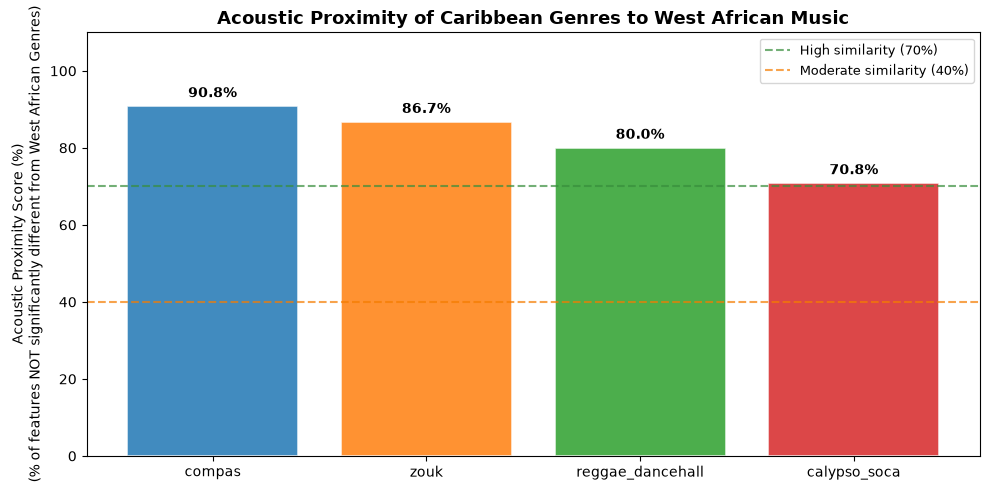

Saved → figure_5_3_proximity_ranking.png


In [27]:
# ── Figure 5.3: Proximity ranking bar chart (goes in Section 5.5) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    proximity['Caribbean Genre'],
    proximity['Acoustic Proximity Score (%)'],
    color=GENRE_PALETTE[:len(proximity)],
    alpha=0.85, edgecolor='white', linewidth=1.2
)
ax.axhline(70, color='#388E3C', linestyle='--', alpha=0.7, label='High similarity (70%)')
ax.axhline(40, color='#F57C00', linestyle='--', alpha=0.7, label='Moderate similarity (40%)')
for bar, val in zip(bars, proximity['Acoustic Proximity Score (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 110)
ax.set_ylabel('Acoustic Proximity Score (%)\n'
              '(% of features NOT significantly different from West African Genres)', fontsize=10)
ax.set_title('Acoustic Proximity of Caribbean Genres to West African Music',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_3_proximity_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figure_5_3_proximity_ranking.png')

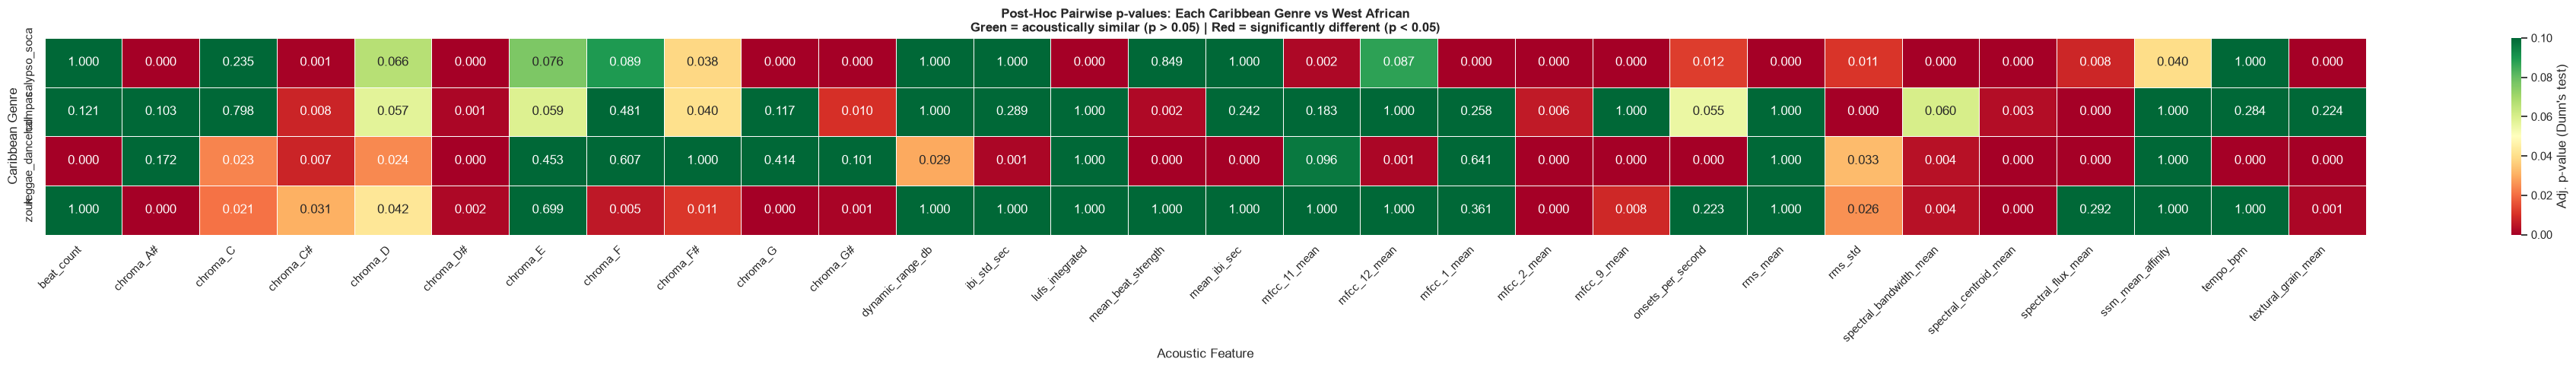

Saved → figure_5_4_posthoc_heatmap.png

Greener rows = that Caribbean genre is most acoustically similar to West African music.
This is Figure 5.4 in your dissertation — put it in Section 5.5.


In [14]:
# ── Figure 5.4: Post-hoc heatmap — p-values per genre per feature ─────────────
# Green cell = that genre is NOT significantly different from West African on that feature
# Red cell   = that genre IS significantly different
# Greener rows = higher acoustic proximity to West African music

pivot = (
    table_54.pivot_table(
        index='Caribbean Genre',
        columns='Feature',
        values="p (Dunn's, adj.)",
        aggfunc='min'
    ).reindex(CARIBBEAN_GENRES)
)

fig, ax = plt.subplots(figsize=(max(10, len(sig_genre_feats) * 1.3), 5))
sns.heatmap(
    pivot, ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=0.1,
    annot=True, fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': "Adj. p-value (Dunn's test)"}
)
ax.set_title(
    'Post-Hoc Pairwise p-values: Each Caribbean Genre vs West African\n'
    'Green = acoustically similar (p > 0.05) | Red = significantly different (p < 0.05)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Acoustic Feature')
ax.set_ylabel('Caribbean Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_4_posthoc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figure_5_4_posthoc_heatmap.png')
print('\nGreener rows = that Caribbean genre is most acoustically similar to West African music.')
print('This is Figure 5.4 in your dissertation — put it in Section 5.5.')

---
## Final Summary  *(feeds Section 5.6 — Chapter Summary)*

In [15]:
sig_feats    = table_52[table_52['Significant'] == 'Yes']['Feature'].tolist()
nonsig_feats = table_52[table_52['Significant'] == 'No']['Feature'].tolist()
top_genre    = proximity.iloc[0]
bot_genre    = proximity.iloc[-1]

print('=' * 65)
print('CHAPTER 5 SUMMARY — copy these numbers into Section 5.6')
print('=' * 65)

print(f'''
 Test Selection
  Total features tested:       {len(table_52)}
  Parametric (normal):         {n_param}
  Non-parametric (non-normal): {n_nonparam}
  Bonferroni α* (corpus):      {alpha_star:.5f}
  Bonferroni α* (genre):       {alpha_g:.5f}

 Corpus Comparisons
  Significant features ({len(sig_feats)}):  {sig_feats}
  Not significant ({len(nonsig_feats)}):      {nonsig_feats}

 Genre Comparisons
  Features varying across genres: {n_sig_g} of {len(table_53)}

 Acoustic Proximity Ranking
''')

for _, r in proximity.iterrows():
    bar = '█' * int(r['Acoustic Proximity Score (%)'] / 5)
    print(f"  {int(r['Rank'])}. {r['Caribbean Genre']:12s}  {r['Acoustic Proximity Score (%)']:5.1f}%  {bar}")

print(f"""
  Most similar to West African:  {top_genre['Caribbean Genre']} """
      f"({top_genre['Acoustic Proximity Score (%)']:.1f}%)")
print(f"  Least similar:                 {bot_genre['Caribbean Genre']} "
      f"({bot_genre['Acoustic Proximity Score (%)']:.1f}%)")

print()
print('FILES SAVED:')
for f in sorted(OUT_DIR.glob('table_5_*')) + \
         sorted(OUT_DIR.glob('figure_5_*')) + \
         sorted(OUT_DIR.glob('acoustic_proximity*')):
    print(f'  {f.name}')

CHAPTER 5 SUMMARY — copy these numbers into Section 5.6

 Test Selection
  Total features tested:       42
  Parametric (normal):         12
  Non-parametric (non-normal): 30
  Bonferroni α* (corpus):      0.00119
  Bonferroni α* (genre):       0.00119

 Corpus Comparisons
  Significant features (11):  ['spectral_centroid_mean', 'mfcc_2_mean', 'textural_grain_mean', 'mfcc_1_mean', 'spectral_bandwidth_mean', 'mfcc_3_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_12_mean', 'lufs_integrated', 'mfcc_11_mean']
  Not significant (31):      ['rms_mean', 'beat_count', 'mean_ibi_sec', 'tempo_bpm', 'chroma_A', 'chroma_F#', 'onsets_per_second', 'chroma_G#', 'chroma_G', 'mfcc_13_mean', 'chroma_E', 'chroma_D#', 'chroma_A#', 'ibi_std_sec', 'chroma_F', 'rms_std', 'mfcc_8_mean', 'chroma_C#', 'ssm_mean_affinity', 'mfcc_4_mean', 'mfcc_7_mean', 'chroma_D', 'mfcc_6_mean', 'dynamic_range_db', 'chroma_B', 'mean_beat_strength', 'key_correlation', 'log_attack_time_ms', 'spectral_flux_mean', 'chroma_C', 'mfcc_5_m